In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import models
import os
import shutil
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import cv2
import yaml
from tqdm import tqdm
from pycocotools import mask as mask_utils
from ultralytics import YOLO
from pathlib import Path
from collections import defaultdict
import random
from glob import glob
import pandas as pd
from PIL import Image

# Data Processing

In [ ]:
data1a_path = "/content/drive/MyDrive/data1a"

In [ ]:
data_transforms = {
    'training': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.6, 1.0)), # look at local details
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # simulate different lightning
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'validation': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [ ]:
image_datasets = {x: datasets.ImageFolder(os.path.join(data1a_path, x), data_transforms[x]) for x in ['training', 'validation']}

In [ ]:
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['training', 'validation']}

In [ ]:
dataset_sizes = {x: len(image_datasets[x]) for x in ['training', 'validation']}
class_names = image_datasets['training'].classes

In [ ]:
assert torch.cuda.is_available(), "CUDA not available — switch runtime to GPU (Runtime > Change runtime type > GPU)"
device = torch.device("cuda")
print("Using device:", torch.cuda.get_device_name(0))
print("CUDA version:", torch.version.cuda, "| torch:", torch.__version__)

# Focal Loss

In [ ]:
class FocalLoss(nn.Module):
  def __init__(self, alpha=0.75, gamma=2, reduction='mean'):
    super(FocalLoss, self).__init__()
    self.alpha = alpha
    self.gamma = gamma
    self.reduction = reduction

  def forward(self, inputs, targets):
    BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
    pt = torch.exp(-BCE_loss)
    F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
    if self.reduction == 'mean':
      return torch.mean(F_loss)
    elif self.reduction == 'sum':
      return torch.sum(F_loss)
    else:
      return F_loss

# Baseline Model: Custom CNN

In [ ]:
class CarDamageCNN(nn.Module):
  def __init__(self):
    super(CarDamageCNN, self).__init__()
    self.features = nn.Sequential(
      nn.Conv2d(3, 32, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2, 2),
      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2, 2),
      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2, 2)
    )
    self.flatten = nn.Flatten()
    self.classifier = nn.Sequential(
      nn.Linear(128 * 28 * 28, 512),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(512, 2)
    )
  def forward(self, x):
    x = self.features(x)
    x = self.flatten(x)
    x = self.classifier(x)
    return x

## Train Model

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
  best_model_wts = copy.deepcopy(model.state_dict())
  best_acc = 0.0
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
  save_dir = "/content/drive/Othercomputers/我的笔记本电脑/Desktop/DUKE/Fall Term 2/DECISION 546Q/Final Project/Training_Results"
  temp_save_path = "/content/temp_custom_cnn_best.pth"
  for epoch in range(num_epochs):
    for phase in ['training', 'validation']:
      if phase == 'training':
        model.train()
      else:
        model.eval()
      running_loss = 0.0
      running_corrects = 0
      for inputs, labels in dataloaders[phase]:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        with torch.set_grad_enabled(phase == 'training'):
          outputs = model(inputs)
          _, preds = torch.max(outputs, 1)
          loss = criterion(outputs, labels)
          if phase == 'training':
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
      epoch_loss = running_loss / dataset_sizes[phase]
      epoch_acc = running_corrects.double() / dataset_sizes[phase]
      if phase == 'training':
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
      else:
        history['val_loss'].append(epoch_loss)
        history['val_acc'].append(epoch_acc.item())
      if phase == 'validation' and epoch_acc > best_acc:
        best_acc = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), temp_save_path)
        final_path = os.path.join(save_dir, 'custom_cnn_best.pth')
        shutil.copy(temp_save_path, final_path)
  print(f'Best val Acc: {best_acc:4f}')
  model.load_state_dict(best_model_wts)
  return model, history

In [ ]:
model_custom = CarDamageCNN().to(device)

In [ ]:
criterion = FocalLoss(alpha=0.75, gamma=2).to(device)
optimizer = optim.Adam(model_custom.parameters(), lr=0.001)

In [ ]:
model_custom, history_custom = train_model(model_custom, criterion, optimizer, num_epochs=15)

Best val Acc: 0.630435


## Plot Training Curves

In [ ]:
def plot_training_history(history, title="Model Training History"):
  acc = history['train_acc']
  val_acc = history['val_acc']
  loss = history['train_loss']
  val_loss = history['val_loss']
  epochs_range = range(len(acc))
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Training Accuracy')
  plt.plot(epochs_range, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.title(f'{title}: Accuracy')
  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Training Loss')
  plt.plot(epochs_range, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title(f'{title}: Loss')
  plt.show()

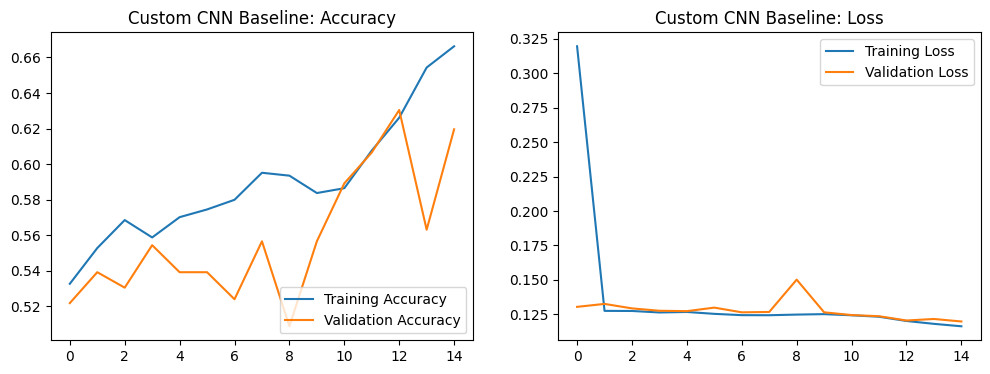

In [ ]:
plot_training_history(history_custom, title="Custom CNN Baseline")

# Transfer Learning from ResNet-18

In [ ]:
model_ft = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 237MB/s]


In [ ]:
for param in model_ft.parameters():
  param.requires_grad = True

In [ ]:
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

In [ ]:
model_ft = model_ft.to(device)

In [ ]:
criterion = FocalLoss(alpha=0.75, gamma=2).to(device)

In [ ]:
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4)

In [ ]:
model_ft, history_resnet = train_model(model_ft, criterion, optimizer_ft, num_epochs=15)

Best val Acc: 0.956522


## Plot Training Curves

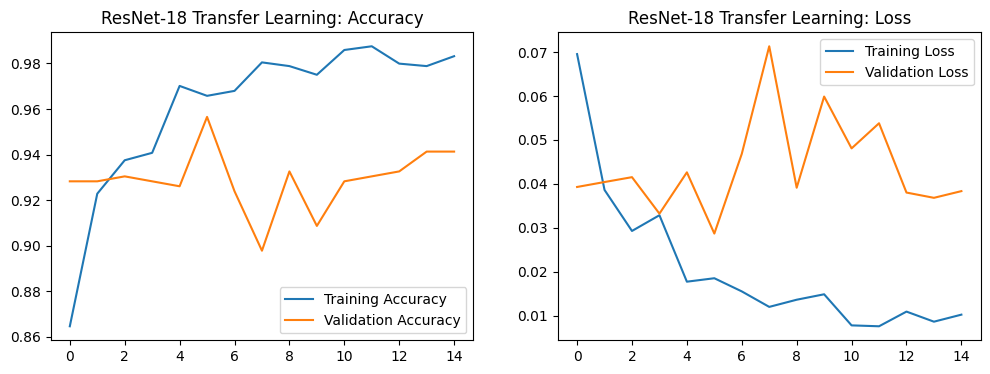

In [ ]:
plot_training_history(history_resnet, title="ResNet-18 Transfer Learning")

## Plot Confusion Matrix

In [ ]:
def plot_confusion_matrix(model, dataloader, class_names):
  model.eval()
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for inputs, labels in dataloader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())
  class_names = ['Damaged', 'Whole']
  print(classification_report(all_labels, all_preds, target_names=class_names))
  cm = confusion_matrix(all_labels, all_preds)
  plt.figure(figsize=(6, 5))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.ylabel('Actual Label')
  plt.xlabel('Predicted Label')
  plt.title('Confusion Matrix (ResNet-18)')
  plt.show()
  return cm

              precision    recall  f1-score   support

     Damaged       0.96      0.95      0.96       230
       Whole       0.95      0.97      0.96       230

    accuracy                           0.96       460
   macro avg       0.96      0.96      0.96       460
weighted avg       0.96      0.96      0.96       460



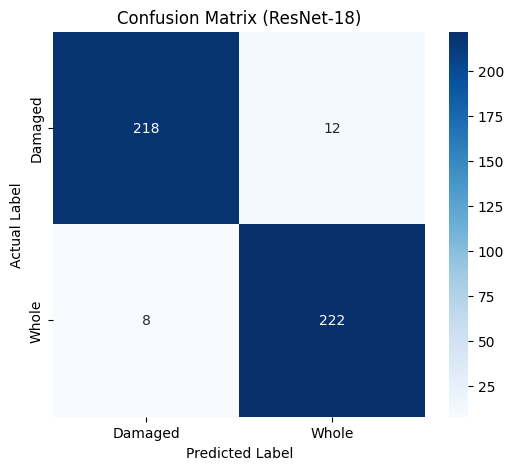

In [ ]:
cm = plot_confusion_matrix(model_ft, dataloaders['validation'], class_names)

# Area/Severity Detection model: segments image so detects the area of damage.

In [ ]:
coco_root = Path("/content/CarDD_COCO")
yolo_root = Path("/content/CARDD_YOLO")

In [ ]:
ann_dir = coco_root / "annotations"
jsons = sorted(ann_dir.glob("*.json"))
train_json = next((p for p in jsons if "train" in p.name.lower()), None)
val_json   = next((p for p in jsons if "val"   in p.name.lower()), None)
test_json  = next((p for p in jsons if "test"  in p.name.lower()), None)

In [ ]:
(yolo_root/"images/train").mkdir(parents=True, exist_ok=True)
(yolo_root/"images/val").mkdir(parents=True, exist_ok=True)

In [ ]:
src_train = coco_root / "train2017"
src_val   = coco_root / "val2017"
!rsync -a --ignore-existing "{src_train}/" "{yolo_root}/images/train/"
!rsync -a --ignore-existing "{src_val}/"   "{yolo_root}/images/val/"

In [ ]:
def coco_to_yolo_seg_labels_only(coco_json_path, out_labels_dir):
  coco = json.loads(Path(coco_json_path).read_text())
  cats = sorted(coco["categories"], key=lambda x: x["id"])
  cat2idx = {c["id"]: i for i, c in enumerate(cats)}
  names = {i: c["name"] for i, c in enumerate(cats)}

  ann_by_img = defaultdict(list)
  for ann in coco["annotations"]:
    ann_by_img[ann["image_id"]].append(ann)

  out_labels_dir = Path(out_labels_dir)
  out_labels_dir.mkdir(parents=True, exist_ok=True)

  for im in tqdm(coco["images"], desc=f"Converting {Path(coco_json_path).stem}"):
    img_id = im["id"]
    file_name = Path(im["file_name"]).name
    w, h = im["width"], im["height"]

    lines = []
    for ann in ann_by_img[img_id]:
      if ann["category_id"] not in cat2idx: continue
      cls = cat2idx[ann["category_id"]]
      seg = ann.get("segmentation", [])
      if isinstance(seg, list):
        for poly in seg:
          if len(poly) < 6: continue # filter out invalid polygons with too few points
          coords = []
          for i in range(0, len(poly), 2):
            coords.append(f"{poly[i]/w:.6f}")
            coords.append(f"{poly[i+1]/h:.6f}")
          lines.append(f"{cls} " + " ".join(coords))
    (out_labels_dir / (Path(file_name).stem + ".txt")).write_text("\n".join(lines) + ("\n" if lines else ""))
  return names

In [ ]:
(yolo_root/"labels/train").mkdir(parents=True, exist_ok=True)
(yolo_root/"labels/val").mkdir(parents=True, exist_ok=True)
names = coco_to_yolo_seg_labels_only(train_json, yolo_root/"labels/train")
_ = coco_to_yolo_seg_labels_only(val_json,   yolo_root/"labels/val")
print("Classes:", names)

Converting instances_val2017: 100%|██████████| 810/810 [00:00<00:00, 6118.79it/s]

Classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}


In [ ]:
data_yaml = yolo_root / "cardd_LOCAL.yaml"
data = {
  "path": str(yolo_root),
  "train": "images/train",
  "val": "images/val",
  "names": {int(k): str(v) for k, v in sorted(names.items())}
}
data_yaml.write_text(yaml.safe_dump(data, sort_keys=False))

154

In [ ]:
for p in yolo_root.rglob("*.cache"):
    p.unlink()
train_imgs = list((yolo_root/"images/train").glob("*"))

In [ ]:
for split in ["train", "val"]:
  p = yolo_root / "images" / split
  if p.is_symlink():
    p.unlink()
  p.mkdir(parents=True, exist_ok=True)

In [ ]:
!rsync -a --ignore-existing "{coco_root}/train2017/" "{yolo_root}/images/train/"
!rsync -a --ignore-existing "{coco_root}/val2017/"   "{yolo_root}/images/val/"

In [ ]:
names = {0:"dent", 1:"scratch", 2:"crack", 3:"glass shatter", 4:"lamp broken", 5:"tire flat"}
local_yaml = yolo_root / "cardd_LOCAL.yaml"
local_yaml.write_text(yaml.safe_dump({
    "path": str(yolo_root),
    "train": "images/train",
    "val": "images/val",
    "names": names
}, sort_keys=False))

154

In [ ]:
for p in glob(str(yolo_root / "**/*.cache"), recursive=True):
  Path(p).unlink()

In [ ]:
save_dir_drive = "/content/drive/Othercomputers/我的笔记本电脑/Desktop/DUKE/Fall Term 2/DECISION 546Q/Final Project/Training_Results/YOLO_Optimized"
model = YOLO("yolov8s-seg.pt")
model.train(
    data=str(local_yaml),
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    project=save_dir_drive,
    name="run_highres_1280",
    patience=15,
    cos_lr=True,
    close_mosaic=10,
    plots=True,
    exist_ok=True
)


In [ ]:
save_dir_drive = Path("/content/drive/Othercomputers/我的笔记本电脑/Desktop/DUKE/Fall Term 2/DECISION 546Q/Final Project/Training_Results/YOLO_Optimized")
candidates = sorted(save_dir_drive.glob("run*"), key=lambda p: p.stat().st_mtime, reverse=True)
best = None
w = candidates[0] / "weights" / "best.pt"
best = str(w)
print("Best model weight:", best)

Best model weight: /content/drive/Othercomputers/我的笔记本电脑/Desktop/DUKE/Fall Term 2/DECISION 546Q/Final Project/Training_Results/YOLO_Optimized/run_highres_1280/weights/best.pt


In [ ]:
data_yaml = "/content/CARDD_YOLO/cardd_LOCAL.yaml"
model = YOLO(best)
m = model.val(data=data_yaml, split="val", device=0, conf=0.25, iou=0.60, imgsz=640)
print("Mask mAP50-95:", m.seg.map, "Mask Precision:", m.seg.mp, "Mask Recall:", m.seg.mr)

In [ ]:
confs = [0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90]
rows = []
for conf in confs:
  m = model.val(data=data_yaml, split="val", device=0, conf=conf, iou=0.60, verbose=False, imgsz=640)
  rows.append({
    "conf": conf,
    "mask_P": float(m.seg.mp),
    "mask_R": float(m.seg.mr),
    "mask_mAP50": float(m.seg.map50),
    "mask_mAP50_95": float(m.seg.map),
    "box_P": float(m.box.mp),
    "box_R": float(m.box.mr),
    "box_mAP50_95": float(m.box.map),
  })
df = pd.DataFrame(rows)
display(df.round(4))

## Plot

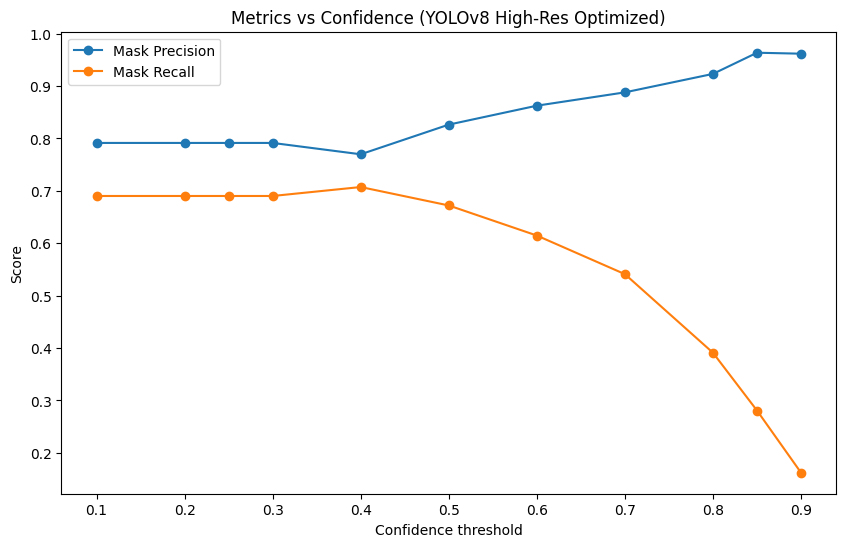

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df["conf"], df["mask_P"], marker="o", label="Mask Precision")
plt.plot(df["conf"], df["mask_R"], marker="o", label="Mask Recall")
plt.xlabel("Confidence threshold")
plt.title("Metrics vs Confidence (YOLOv8 High-Res Optimized)")
plt.ylabel("Score")
plt.legend()
plt.show()

In [ ]:
target_P = 0.90
best_prec_first = df[df["mask_P"] >= target_P].sort_values("mask_R", ascending=False).head(1)
print("Best precision-first (P>={:.2f}):".format(target_P))
display(best_prec_first[["conf","mask_P","mask_R","mask_mAP50_95"]])

#Best conf by F1
df["mask_F1"] = 2*df["mask_P"]*df["mask_R"]/(df["mask_P"]+df["mask_R"])
best_f1 = df.sort_values("mask_F1", ascending=False).head(1)
print("Best F1:")
display(best_f1[["conf","mask_P","mask_R","mask_F1","mask_mAP50_95"]])

Best precision-first (P>=0.90):


,conf,mask_P,mask_R,mask_mAP50_95
8,0.8,0.923249,0.391011,0.527089


Best F1:


,conf,mask_P,mask_R,mask_F1,mask_mAP50_95
5,0.5,0.826438,0.672141,0.741346,0.558751


In [ ]:
p = Path("/content/drive/MyDrive/data1a/validation")
print("Subfolders:", [x.name for x in p.iterdir() if x.is_dir()])
exts = ["*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG","*.webp","*.WEBP"]
imgs = []
for e in exts:
  imgs += list(p.rglob(e))
print("Found images:", len(imgs))
print("Sample paths:", [str(x) for x in imgs[:5]])

Subfolders: ['00-damage', '01-whole']
Found images: 460
Sample paths: ['/content/drive/MyDrive/data1a/validation/01-whole/0013.jpg', '/content/drive/MyDrive/data1a/validation/01-whole/0010.jpg', '/content/drive/MyDrive/data1a/validation/01-whole/0015.jpg', '/content/drive/MyDrive/data1a/validation/01-whole/0006.jpg', '/content/drive/MyDrive/data1a/validation/01-whole/0017.jpg']


## Predict on clean cars to check false positives

In [ ]:
clean_dir = Path("/content/drive/MyDrive/data1a/validation/01-whole")

def fp_rate_batched(model, folder, conf=0.80, iou=0.60, min_area_frac=0.001, batch_size=4, imgsz=640):
  imgs = sorted([p for p in folder.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
  n = len(imgs)
  fp_imgs = 0
  total_masks = 0
  for i in range(0, n, batch_size):
    batch = [str(p) for p in imgs[i:i+batch_size]]
    results = model.predict(batch, conf=conf, iou=iou, imgsz=imgsz, verbose=False)
    for r in results:
      keep = 0
      if r.masks is not None:
        m = r.masks.data
        H, W = int(m.shape[1]), int(m.shape[2])
        areas = (m.sum(dim=(1,2)) / float(H*W)).detach().cpu().numpy()
        keep = int((areas >= min_area_frac).sum())
        total_masks += keep
        if keep > 0:
          fp_imgs += 1
    del results
    torch.cuda.empty_cache()

  return fp_imgs, n, fp_imgs/n if n else 0, total_masks

In [ ]:
fp, n, rate, masks = fp_rate_batched(model, clean_dir, conf=0.70, batch_size=4, imgsz=640)
print(f"FP image rate @conf=0.70: {fp}/{n} = {rate:.2%} | masks kept total: {masks}")

In [ ]:
for c in [0.70, 0.75, 0.80, 0.85]:
  fp, n, rate, masks = fp_rate_batched(model, clean_dir, conf=c, batch_size=4, imgsz=640)
  print(f"conf={c:.2f} | FP images {fp}/{n} = {rate:.2%} | masks {masks}")

In [ ]:
damage_dir = "/content/drive/MyDrive/data1a/validation/00-damage"

model.predict(
    source=damage_dir,
    conf=0.25,
    iou=0.60,
    imgsz=640,
    save=True,
    save_txt=True,
    save_conf=True,
    project="runs/olddata_preds",
    name="damage_highres_inference",
    exist_ok=True
)
print("Outputs in: /content/runs/olddata_preds/damage_highres_inference/")

In [ ]:
out_dir = Path("runs/olddata_preds/damage_highres_inference")
labels_dir = out_dir / "labels"

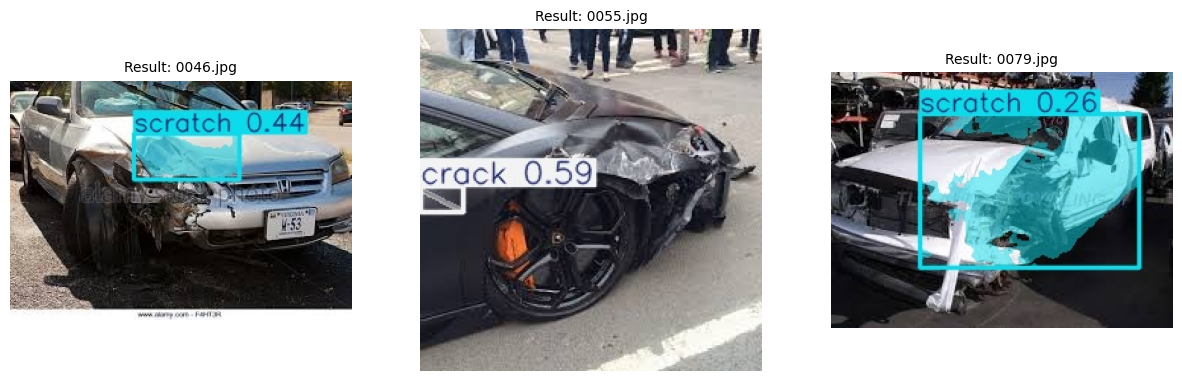

In [ ]:
result_imgs = list(out_dir.glob("*.jpg")) + list(out_dir.glob("*.jpeg"))
samples = random.sample(result_imgs, min(3, len(result_imgs)))
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(samples):
  plt.subplot(1, 3, i+1)
  plt.imshow(Image.open(img_path))
  plt.axis("off")
  plt.title(f"Result: {img_path.name}", fontsize=10)
plt.show()

In [ ]:
image_dir = Path("/content/CarDD_COCO/val2017")
best_model_path = Path("/content/drive/Othercomputers/我的笔记本电脑/Desktop/DUKE/Fall Term 2/DECISION 546Q/Final Project/Training_Results/YOLO_Optimized/run_highres_1280/weights/best.pt")
test_imgs = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.jpeg"))
target_img = random.choice(test_imgs)
print(f"Processing image: {target_img.name}")
model = YOLO(str(best_model_path))
results = model.predict(str(target_img), conf=0.25, iou=0.60, imgsz=640, verbose=False)
r = results[0]
plt.figure(figsize=(10, 8))
plt.imshow(r.plot())
plt.axis("off")
plt.title(f"Inference Result: {target_img.name}")
plt.show()
print("Detection Results:")
for box in r.boxes:
  print(f" - {r.names[int(box.cls[0])]} ({float(box.conf[0]):.2f})")

# Deployment & Inference Demo

In [ ]:
class DamageAnalysisSystem:
  def __init__(self, yolo_path):
    self.segmenter = YOLO(yolo_path)

  def process_claim(self, image_path):
    result = {"file": Path(image_path).name}
    yolo_res = self.segmenter.predict(image_path, conf=0.25, imgsz=640, verbose=False)[0]
    result["plot"] = yolo_res.plot()
    det_info = []
    if yolo_res.boxes:
      for box in yolo_res.boxes:
        cls_name = yolo_res.names[int(box.cls[0])]
        conf = float(box.conf[0])
        det_info.append(f"{cls_name} ({conf:.2f})")

      result["status"] = "DAMAGE DETECTED"
      result["detections"] = det_info
    else:
      result["status"] = "NO DAMAGE FOUND"
      result["detections"] = []

    return result

yolo_path = "/content/drive/Othercomputers/我的笔记本电脑/Desktop/DUKE/Fall Term 2/DECISION 546Q/Final Project/Training_Results/YOLO_Optimized/run_highres_1280/weights/best.pt"

system = DamageAnalysisSystem(yolo_path)

image_pool = Path("/content/CarDD_COCO/val2017")
test_file = random.choice(list(image_pool.glob("*.jpg")))

print(f"Processing New Claim: {test_file.name}")
report = system.process_claim(str(test_file))
print(f"FINAL REPORT")
print(f"Status:     {report['status']}")
print(f"Detections: {report['detections']}")

if report["plot"] is not None:
  plt.figure(figsize=(10, 8))
  plt.imshow(report["plot"])
  plt.axis("off")
  plt.title(f"System Output: {report['status']}")
  plt.show()
else:
  plt.imshow(Image.open(test_file))
  plt.axis("off")
  plt.title("System Output: No Damage")
  plt.show()